In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

import smarts_cerebellum.globals as gl

In [2]:
# all regions minus vermis bc anti-vermis club!
"""
array(['M1L', 'M2L', 'M3L', 'M4L', 'A1L', 'A2L', 'A3L', 'D1L', 'D2L',
       'D3L', 'D4L', 'S1L', 'S2L', 'S3L', 'S4L', 'S5L', 'M1R', 'M2R',
       'M3R', 'M4R', 'A1R', 'A2R', 'A3R', 'D1R', 'D2R', 'D3R', 'D4R',
       'S1R', 'S2R', 'S3R', 'S4R', 'S5R'], dtype=object)
"""

"\narray(['M1L', 'M2L', 'M3L', 'M4L', 'A1L', 'A2L', 'A3L', 'D1L', 'D2L',\n       'D3L', 'D4L', 'S1L', 'S2L', 'S3L', 'S4L', 'S5L', 'M1R', 'M2R',\n       'M3R', 'M4R', 'A1R', 'A2R', 'A3R', 'D1R', 'D2R', 'D3R', 'D4R',\n       'S1R', 'S2R', 'S3R', 'S4R', 'S5R'], dtype=object)\n"

In [3]:
regions = ['M1L', 'M2L', 'M3L', 'M4L', 'M1R', 'M2R','M3R', 'M4R']

reds = sns.color_palette("Reds", n_colors=len(regions)//2)
blues = sns.color_palette("Blues", n_colors=len(regions)//2)


## Modulated GM volume

convergence warnings

In [4]:
# currently avaialble: 'GM_mod', 'T1'
segment = 'GM'

# observed means
patients_actual = pd.read_csv(os.path.join(gl.baseDir, f'MNISymC_{segment}', 'means', f'summary_patients_MNISymC_Nettekoven_2024_{segment}_mod_mean.tsv'), sep = '\t')
controls_actual = pd.read_csv(os.path.join(gl.baseDir, f'MNISymC_{segment}', 'means', f'summary_controls_MNISymC_Nettekoven_2024_{segment}_mod_mean.tsv'), sep = '\t')

# estimated means
patients_lme = pd.read_csv(os.path.join(gl.baseDir, 'lme', f'patients_MNISymC_{segment}_mod_Nettekoven_2024_lme.tsv'), sep = '\t')
controls_lme = pd.read_csv(os.path.join(gl.baseDir, 'lme', f'controls_MNISymC_{segment}_mod_Nettekoven_2024_lme.tsv'), sep = '\t')

# specify regions
patients_lme = patients_lme[patients_lme.regionname.isin(regions)]
controls_lme = controls_lme[controls_lme.regionname.isin(regions)]
patients_actual = patients_actual[patients_actual.regionname.isin(regions)]
controls_actual = controls_actual[controls_actual.regionname.isin(regions)]

# get hemisphere
patients_lme['hemisphere'] = patients_lme.regionname.str[2]
controls_lme['hemisphere'] = controls_lme.regionname.str[2]
patients_actual['hemisphere'] = patients_actual.regionname.str[2]
controls_actual['hemisphere'] = controls_actual.regionname.str[2]

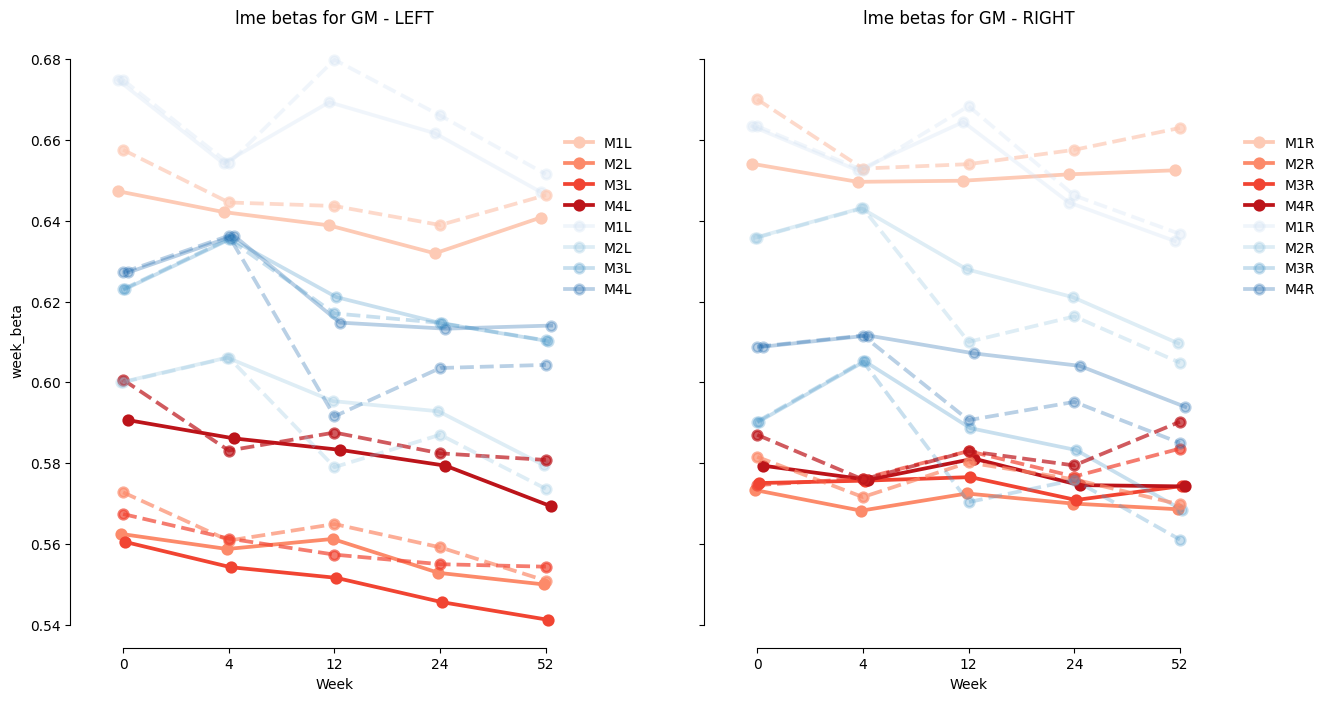

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(15,8), sharey = True)

# left hemisphere
sns.pointplot(data = patients_lme[patients_lme.hemisphere == 'L'], x = 'Week', y = 'week_beta', hue = 'regionname', palette = reds, alpha = 1, dodge = True, ax = ax[0])
sns.pointplot(data = controls_lme[controls_lme.hemisphere == 'L'], x = 'Week', y = 'week_beta', hue = 'regionname', palette = blues, alpha = 0.3, dodge = True, ax = ax[0])

sns.pointplot(data = patients_actual[patients_actual.hemisphere == 'L'], x = 'Week', y = 'mean', hue = 'regionname', palette = reds, alpha = 0.7, linestyle = '--', ax = ax[0], legend = False)
sns.pointplot(data = controls_actual[controls_actual.hemisphere == 'L'], x = 'Week', y = 'mean', hue = 'regionname', palette = blues, alpha = 0.3, linestyle = '--', ax = ax[0], legend = False)

ax[0].set_title(f'lme betas for {segment} - LEFT')
ax[0].legend(bbox_to_anchor = (1, .7), loc = 'center', frameon = False)



# right hemisphere
sns.pointplot(data = patients_lme[patients_lme.hemisphere == 'R'], x = 'Week', y = 'week_beta', hue = 'regionname', palette = reds, alpha = 1, dodge = True, ax = ax[1])
sns.pointplot(data = controls_lme[controls_lme.hemisphere == 'R'], x = 'Week', y = 'week_beta', hue = 'regionname', palette = blues, alpha = 0.3, dodge = True, ax = ax[1])

sns.pointplot(data = patients_actual[patients_actual.hemisphere == 'R'], x = 'Week', y = 'mean', hue = 'regionname', palette = reds, alpha = 0.7, linestyle = '--', ax = ax[1], legend = False)
sns.pointplot(data = controls_actual[controls_actual.hemisphere == 'R'], x = 'Week', y = 'mean', hue = 'regionname', palette = blues, alpha = 0.3, linestyle = '--', ax = ax[1], legend = False)

ax[1].set_title(f'lme betas for {segment} - RIGHT')
ax[1].legend(bbox_to_anchor = (1, .7), loc = 'center left', frameon = False)


sns.despine(trim = True)
plt.show()

## T1

In [6]:
# currently avaialble: 'WM_mod', 'T1'
segment = 'T1'

# observed means
patients_actual = pd.read_csv(os.path.join(gl.baseDir, f'MNISymC_{segment}', 'means', f'summary_patients_MNISymC_Nettekoven_2024_{segment}_mean.tsv'), sep = '\t')
controls_actual = pd.read_csv(os.path.join(gl.baseDir, f'MNISymC_{segment}', 'means', f'summary_controls_MNISymC_Nettekoven_2024_{segment}_mean.tsv'), sep = '\t')

# estimated means
patients_lme = pd.read_csv(os.path.join(gl.baseDir, 'lme', f'patients_MNISymC_{segment}_Nettekoven_2024_lme.tsv'), sep = '\t')
controls_lme = pd.read_csv(os.path.join(gl.baseDir, 'lme', f'controls_MNISymC_{segment}_Nettekoven_2024_lme.tsv'), sep = '\t')


# specify regions
patients_lme = patients_lme[patients_lme.regionname.isin(regions)]
controls_lme = controls_lme[controls_lme.regionname.isin(regions)]
patients_actual = patients_actual[patients_actual.regionname.isin(regions)]
controls_actual = controls_actual[controls_actual.regionname.isin(regions)]

# get hemisphere
patients_lme['hemisphere'] = patients_lme.regionname.str[2]
controls_lme['hemisphere'] = controls_lme.regionname.str[2]
patients_actual['hemisphere'] = patients_actual.regionname.str[2]
controls_actual['hemisphere'] = controls_actual.regionname.str[2]

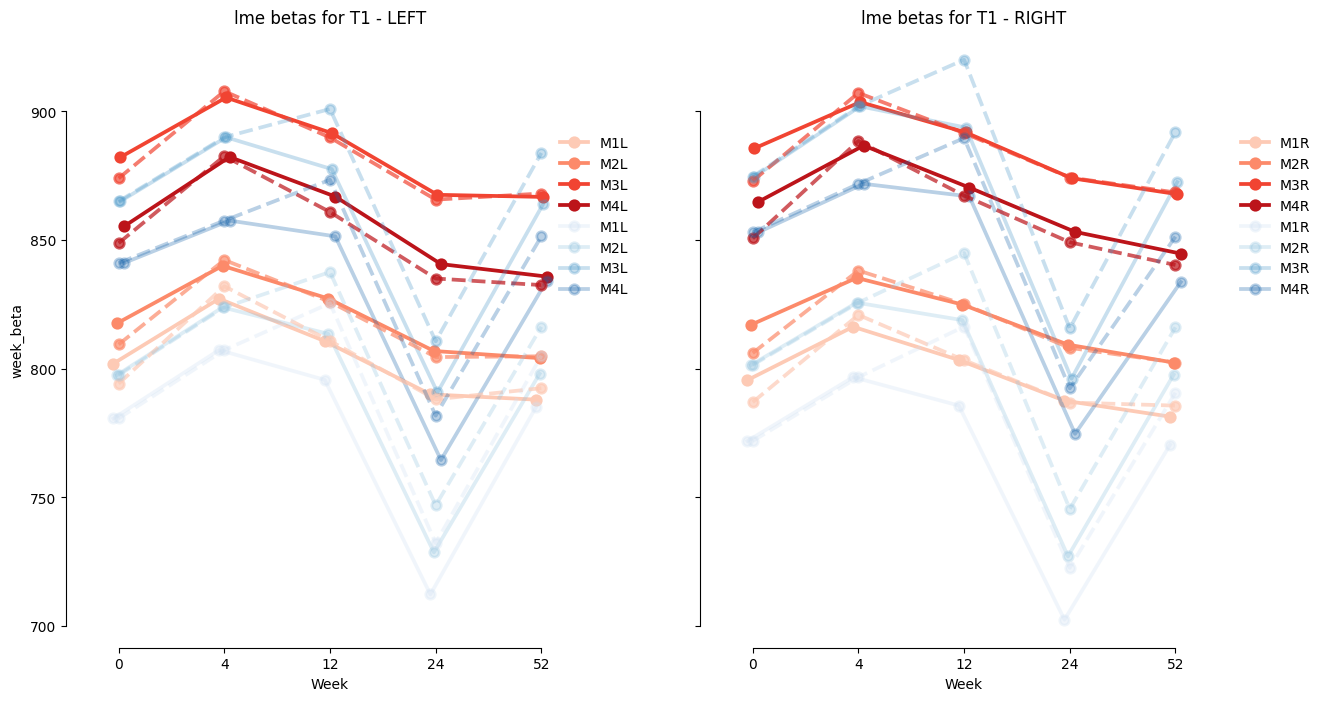

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(15,8), sharey = True)

# left hemisphere
sns.pointplot(data = patients_lme[patients_lme.hemisphere == 'L'], x = 'Week', y = 'week_beta', hue = 'regionname', palette = reds, alpha = 1, dodge = True, ax = ax[0])
sns.pointplot(data = controls_lme[controls_lme.hemisphere == 'L'], x = 'Week', y = 'week_beta', hue = 'regionname', palette = blues, alpha = 0.3, dodge = True, ax = ax[0])

sns.pointplot(data = patients_actual[patients_actual.hemisphere == 'L'], x = 'Week', y = 'mean', hue = 'regionname', palette = reds, alpha = 0.7, linestyle = '--', ax = ax[0], legend = False)
sns.pointplot(data = controls_actual[controls_actual.hemisphere == 'L'], x = 'Week', y = 'mean', hue = 'regionname', palette = blues, alpha = 0.3, linestyle = '--', ax = ax[0], legend = False)

ax[0].set_title(f'lme betas for {segment} - LEFT')
ax[0].legend(bbox_to_anchor = (1, .7), loc = 'center', frameon = False)



# right hemisphere
sns.pointplot(data = patients_lme[patients_lme.hemisphere == 'R'], x = 'Week', y = 'week_beta', hue = 'regionname', palette = reds, alpha = 1, dodge = True, ax = ax[1])
sns.pointplot(data = controls_lme[controls_lme.hemisphere == 'R'], x = 'Week', y = 'week_beta', hue = 'regionname', palette = blues, alpha = 0.3, dodge = True, ax = ax[1])

sns.pointplot(data = patients_actual[patients_actual.hemisphere == 'R'], x = 'Week', y = 'mean', hue = 'regionname', palette = reds, alpha = 0.7, linestyle = '--', ax = ax[1], legend = False)
sns.pointplot(data = controls_actual[controls_actual.hemisphere == 'R'], x = 'Week', y = 'mean', hue = 'regionname', palette = blues, alpha = 0.3, linestyle = '--', ax = ax[1], legend = False)

ax[1].set_title(f'lme betas for {segment} - RIGHT')
ax[1].legend(bbox_to_anchor = (1, .7), loc = 'center left', frameon = False)


sns.despine(trim = True)
plt.show()